In [1]:
load('.RData')

In [6]:
library(ropls)
library(ggplot2)
library(ggpubr)
library(RColorBrewer)
library(HotellingEllipse)
library(ggforce)
library(caret)

In [4]:
head(df_wot) #### Hemos eliminado los outliers

,MouseID,Genotype,Treatment,Behavior,class,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,⋯,P3525_N,pCASP9_N,PSD95_N,SNCA_N,Ubiquitin_N,pGSK3B_Tyr216_N,SHH_N,pS6_N,SYP_N,CaNA_N
,<chr>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,309_1,c,m,CS,cCSm,0.5036439,0.7471932,0.4301753,2.816329,5.990152,⋯,0.2475378,1.603310,2.014875,0.1082343,1.0449792,0.8315565,0.1888517,0.1063052,0.4270992,1.675652
2,309_2,c,m,CS,cCSm,0.5146171,0.6890635,0.4117703,2.789514,5.685038,⋯,0.2576322,1.671738,2.004605,0.1097485,1.0098831,0.8492704,0.2004036,0.1065922,0.4415813,1.743610
3,309_3,c,m,CS,cCSm,0.5091831,0.7302468,0.4183088,2.687201,5.622059,⋯,0.2553430,1.663550,2.016831,0.1081962,0.9968476,0.8467087,0.1936845,0.1083031,0.4357769,1.926427
4,309_4,c,m,CS,cCSm,0.4421067,0.6170762,0.3586263,2.466947,4.979503,⋯,0.2511031,1.484624,1.957233,0.1198832,0.9902247,0.8332768,0.1921119,0.1031838,0.3916910,1.700563
5,309_5,c,m,CS,cCSm,0.4349402,0.6174298,0.3588022,2.365785,4.718679,⋯,0.2517730,1.534835,2.009109,0.1195244,0.9977750,0.8786678,0.2056042,0.1047838,0.4341538,1.839730
6,309_6,c,m,CS,cCSm,0.4475064,0.6281758,0.3673881,2.385939,4.807635,⋯,0.2444853,1.507777,2.003535,0.1206872,0.9201782,0.8436793,0.1904695,0.1064762,0.4398331,1.816389


In [8]:
#### separar datos en training y test
set.seed(12345)
index <- createDataPartition(df_wot$Behavior, p = 0.75, list = FALSE)
train_data <- df_wot[index, ]
test_data <- df_wot[-index, ]
sprintf("The trainining set contains %d rows", nrow(train_data))
sprintf("The test set contains %d rows", nrow(test_data))

[1] "The trainining set contains 779 rows"

[1] "The test set contains 259 rows"

In [9]:
table(train_data$Behavior) ## Mas o menos equilibradas (48% vs 52%)


 CS  SC 
376 403 

PLS-DA
779 samples x 71 variables and 1 response
standard scaling of predictors and response(s)
      R2X(cum) R2Y(cum) Q2(cum) RMSEE pre ort  pR2Y   pQ2
Total    0.491     0.88   0.877 0.174   3   0 0.001 0.001


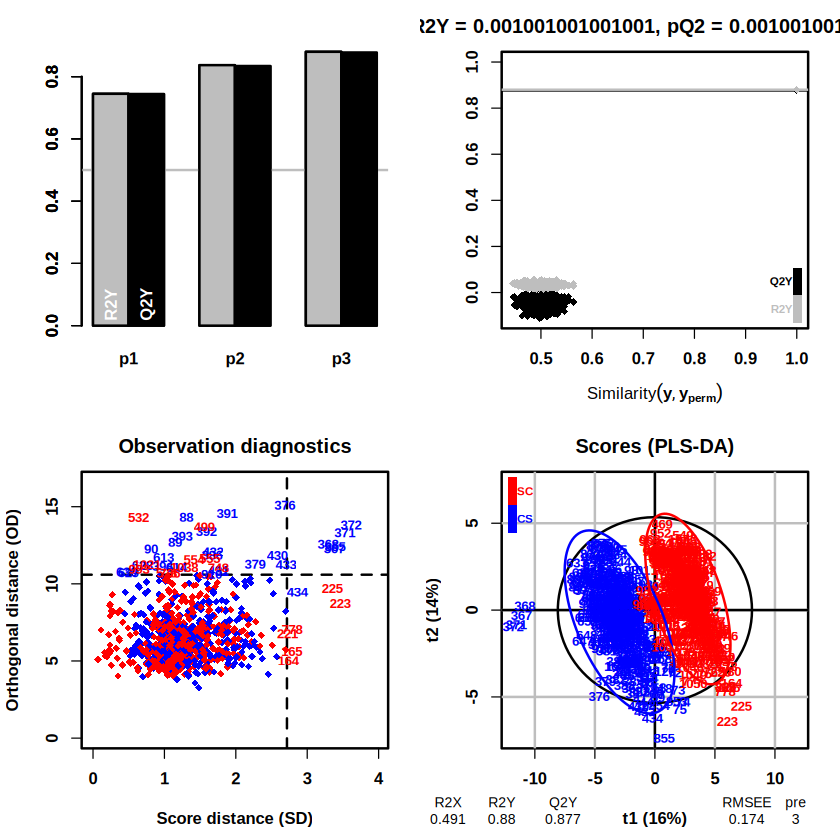

In [31]:
res.plsda <- opls(train_data[, 6:76], train_data$Behavior, 
                  algoC = 'nipals', scaleC = 'standard', 
                  permI = 999, predI = 3)

In [25]:
res.plsda@modelDF

,R2X,R2X(cum),R2Y,R2Y(cum),Q2,Q2(cum),Signif.,Iter.
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
p1,0.161,0.161,0.7450,0.745,0.744,0.744,R1,1
p2,0.140,0.301,0.0917,0.837,0.352,0.834,R1,1
p3,0.190,0.491,0.0429,0.880,0.258,0.877,R1,1


In [26]:
scores <- getScoreMN(res.plsda)

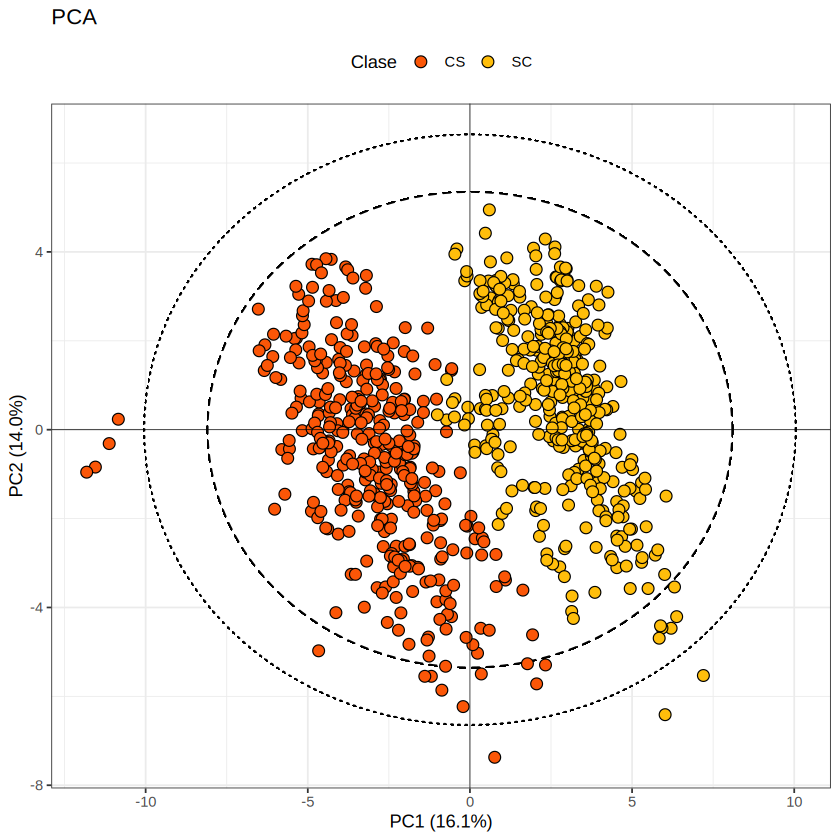

In [29]:
res_2PCs <- ellipseParam(data = as.data.frame(scores),
                        k = 2, pcx = 1, pcy = 2)
a1 <- res_2PCs$Ellipse$a.99pct
b1 <- res_2PCs$Ellipse$b.99pct
a2 <- res_2PCs$Ellipse$a.95pct
b2 <- res_2PCs$Ellipse$b.95pct

pb <- ggplot(as.data.frame(scores), aes(x = p1, y = p2)) +
        geom_ellipse(aes(x0 = 0, y0 = 0, a = a1, b = b1, angle = 0), size = .5, 
                     linetype = "dotted", fill = "white") +
        geom_ellipse(aes(x0 = 0, y0 = 0, a = a2, b = b2, angle = 0), size = .5, 
                     linetype = "dashed", fill = "white") +
        geom_point(aes(fill = train_data$Behavior), color = 'black', shape = 21, size = 3) +
        scale_fill_manual(values = Behavior_color) +
        geom_hline(yintercept = 0, linetype = "solid", color = "black", size = .2) +
        geom_vline(xintercept = 0, linetype = "solid", color = "black", size = .2) +
        theme_bw() + 
        theme(legend.position = 'top') +
        labs(title = 'PCA', fill = 'Clase') +
        xlab('PC1 (16.1%)') + 
        ylab('PC2 (14.0%)')
pb

In [32]:
head(res.plsda@suppLs[['permMN']])

R2X(cum),R2Y(cum),Q2(cum),RMSEE,pre,ort,sim
0.491,0.8800,0.8770,0.174,3,0,1.0000000
0.455,0.0404,-0.0649,0.491,3,0,0.4890886
0.419,0.0299,-0.0585,0.493,3,0,0.5070603
0.456,0.0319,-0.0601,0.493,3,0,0.4967908
0.469,0.0309,-0.0516,0.493,3,0,0.5096277
0.301,0.0496,-0.0419,0.488,3,0,0.5121951


In [33]:
x0 <- 1
y0 <- 0.8770

lm.model_q2 <- lm(I(`Q2(cum)` - y0) ~ I(sim - x0) + 0, 
               data = as.data.frame(res.plsda@suppLs[['permMN']]))
lm.model_q2
predicted_q2 <- predict(lm.model_q2, data.frame(sim = seq(0, 1, by = 0.1)))
df_predicted_q2 <- data.frame(sim = seq(0, 1, by = 0.1), pred = predicted_q2)


Call:
lm(formula = I(`Q2(cum)` - y0) ~ I(sim - x0) + 0, data = as.data.frame(res.plsda@suppLs[["permMN"]]))

Coefficients:
I(sim - x0)  
       1.85  


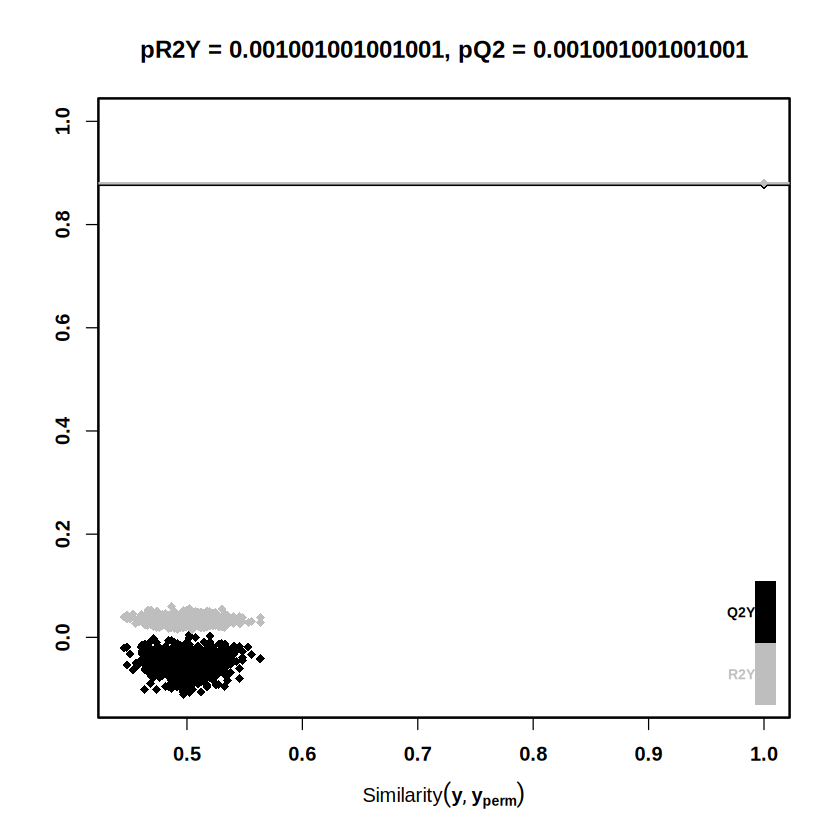

In [42]:
plot(res.plsda, typeVc = 'permutation')
# La intersección negativa de la línea de tendencia Q2Y indica que el modelo ajusta los
# datos y que la clasificación no es fortuita. Los plots de validación para todos los
# modelos indican su validez.

In [46]:
df_scores <- cbind(as.data.frame(scores[, 1:2]), Behavior = train_data$Behavior)
head(df_scores)

,p1,p2,Behavior
,<dbl>,<dbl>,<fct>
1,-4.363701,-0.681363617,CS
2,-4.424957,-0.322284426,CS
3,-4.630894,-0.395755428,CS
5,-3.918932,0.006118036,CS
6,-4.100313,0.135129595,CS
7,-3.474451,-0.093573646,CS


In [52]:
t_test <- t.test(df_scores[df_scores$Behavior == 'CS', ]$p1, df_scores[df_scores$Behavior == 'SC', ]$p1)
t_test
t_test <- t.test(df_scores[df_scores$Behavior == 'CS', ]$p2, df_scores[df_scores$Behavior == 'SC', ]$p2)
t_test


	Welch Two Sample t-test

data:  df_scores[df_scores$Behavior == "CS", ]$p1 and df_scores[df_scores$Behavior == "SC", ]$p1
t = -47.234, df = 706.73, p-value < 2.2e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -5.924823 -5.451934
sample estimates:
mean of x mean of y 
-2.942768  2.745610 



	Welch Two Sample t-test

data:  df_scores[df_scores$Behavior == "CS", ]$p2 and df_scores[df_scores$Behavior == "SC", ]$p2
t = -8.8342, df = 762.13, p-value < 2.2e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -1.612731 -1.026304
sample estimates:
 mean of x  mean of y 
-0.6826257  0.6368915 


#### OPLSDA

Warning message:
“OPLS: number of predictive components ('predI' argument) set to 1”


OPLS-DA
779 samples x 71 variables and 1 response
standard scaling of predictors and response(s)
      R2X(cum) R2Y(cum) Q2(cum) RMSEE pre ort   pR2Y    pQ2
Total    0.301    0.837   0.834 0.202   1   1 0.0101 0.0101


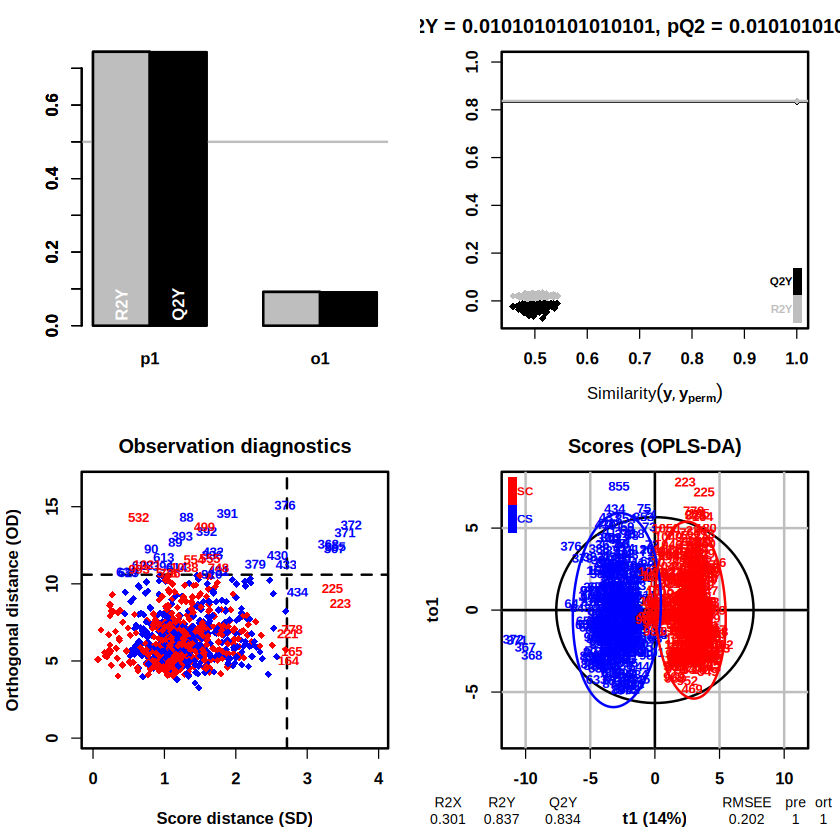

In [73]:
res.oplsda <- opls(train_data[, 6:76], train_data$Behavior, 
                  algoC = 'nipals', scaleC = 'standard', 
                  permI = 99, orthoI = 1)

In [74]:
res.oplsda@modelDF

,R2X,R2X(cum),R2Y,R2Y(cum),Q2,Q2(cum),Signif.
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
p1,0.144,0.144,0.7450,0.7450,0.7440,0.7440,R1
o1,0.157,0.301,0.0917,0.0917,0.0904,0.0904,R1
sum,NA,0.301,NA,0.8370,NA,0.8340,NA


,p1,o1
1,-4.207399,-0.3308719
2,-4.092316,-0.7041603
3,-4.310394,-0.6784601
5,-3.486605,-0.9151816
6,-3.587167,-1.0862677
7,-3.137925,-0.7123851


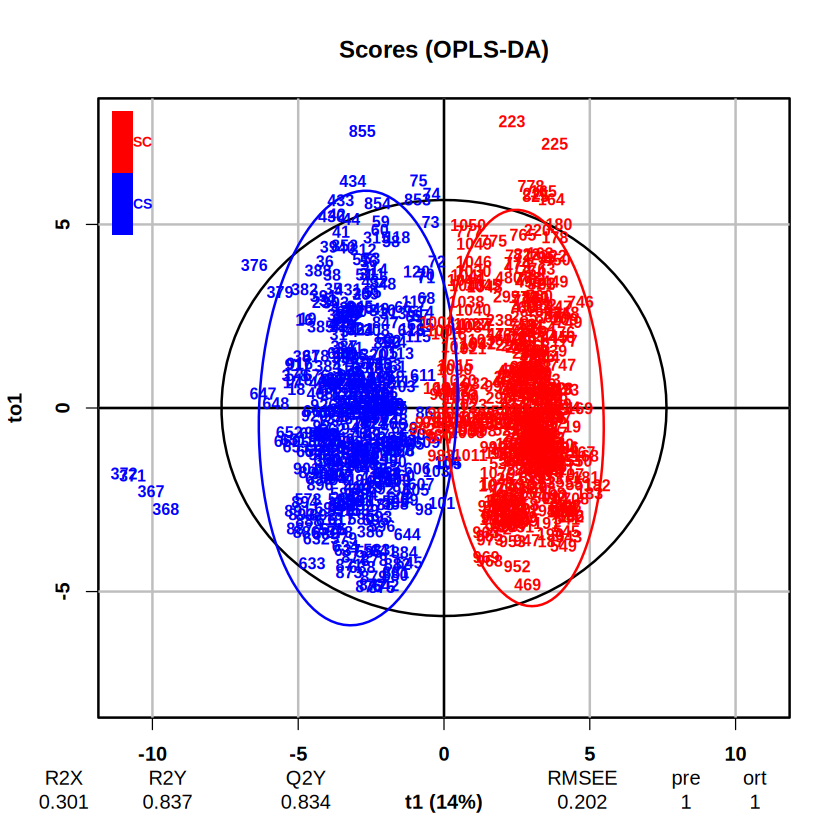

In [80]:
scores <- getScoreMN(res.oplsda)
o_scores <- res.oplsda@orthoScoreMN
scores <- cbind(scores, o_scores)
head(scores)
plot(res.oplsda, typeVc = 'x-score')

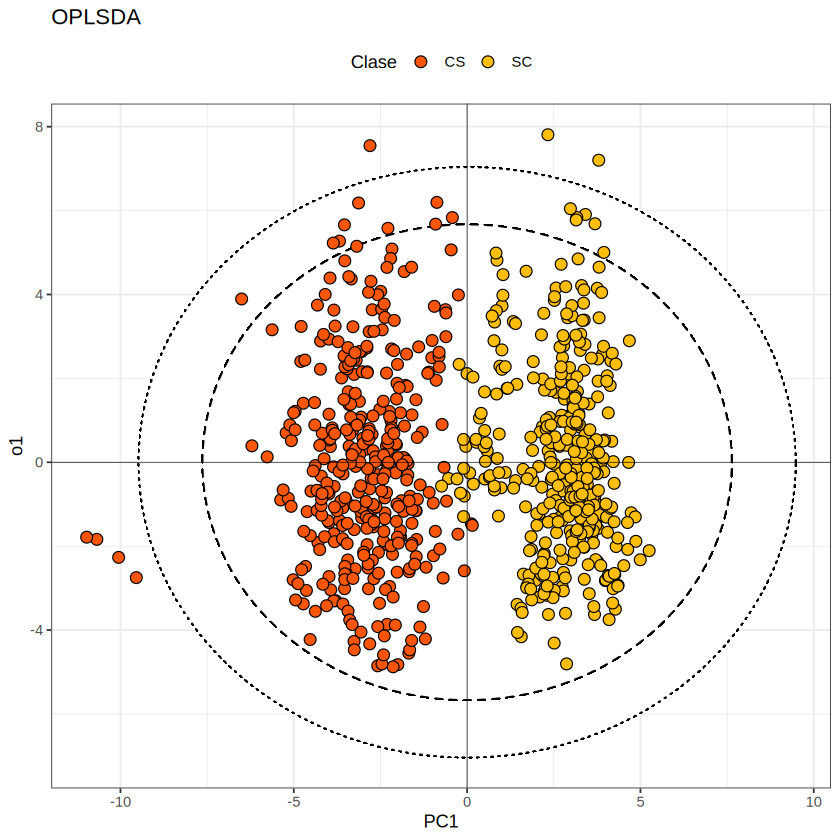

In [79]:
res_2PCs <- ellipseParam(data = as.data.frame(scores),
                        k = 2, pcx = 1, pcy = 2)
a1 <- res_2PCs$Ellipse$a.99pct
b1 <- res_2PCs$Ellipse$b.99pct
a2 <- res_2PCs$Ellipse$a.95pct
b2 <- res_2PCs$Ellipse$b.95pct

pb <- ggplot(as.data.frame(scores), aes(x = p1, y = o1)) +
        geom_ellipse(aes(x0 = 0, y0 = 0, a = a1, b = b1, angle = 0), size = .5, 
                     linetype = "dotted", fill = "white") +
        geom_ellipse(aes(x0 = 0, y0 = 0, a = a2, b = b2, angle = 0), size = .5, 
                     linetype = "dashed", fill = "white") +
        geom_point(aes(fill = train_data$Behavior), color = 'black', shape = 21, size = 3) +
        scale_fill_manual(values = Behavior_color) +
        geom_hline(yintercept = 0, linetype = "solid", color = "black", size = .2) +
        geom_vline(xintercept = 0, linetype = "solid", color = "black", size = .2) +
        theme_bw() + 
        theme(legend.position = 'top') +
        labs(title = 'OPLSDA', fill = 'Clase') +
        xlab('PC1') + 
        ylab('o1')
pb

In [81]:
############################
#######    S-PLOT ##########
############################
DataSplot <- function(datamatrix, opls) {

  s <- datamatrix
  T <- as.matrix(opls@scoreMN)

  p1 <- c()
  for (i in 1:ncol(s)) {
    scov <- cov(s[,i], T)
    p1 <- matrix(c(p1, scov), ncol=1)
  }

  pcorr1 <- c()
  for (i in 1:nrow(p1)) {
    den <- apply(T, 2, sd)*sd(s[,i])
    corr1 <- p1[i,]/den
    pcorr1 <- matrix(c(pcorr1, corr1), ncol=1)
  }

  datasplot <- data.frame(Cov = p1, Corr = pcorr1)
  rownames(datasplot) <- colnames(datamatrix)

  return(datasplot)
}

In [148]:
df_vip <- data.frame(vip = getVipVn(res.oplsda), var = names(getVipVn(res.oplsda)))
df_vip <- df_vip[order(df_vip$vip, decreasing = TRUE), ]
head(df_vip)
df_vip$var

,vip,var
,<dbl>,<chr>
pERK_N,2.121891,pERK_N
CaNA_N,2.041023,CaNA_N
DYRK1A_N,2.006807,DYRK1A_N
SOD1_N,1.971522,SOD1_N
ITSN1_N,1.951583,ITSN1_N
BRAF_N,1.874058,BRAF_N


[1] "pERK_N"          "CaNA_N"          "DYRK1A_N"        "SOD1_N"         
 [5] "ITSN1_N"         "BRAF_N"          "GSK3B_N"         "P38_N"          
 [9] "pPKCAB_N"        "Ubiquitin_N"     "ARC_N"           "pS6_N"          
[13] "pGSK3B_N"        "SNCA_N"          "IL1B_N"          "S6_N"           
[17] "ERK_N"           "pNUMB_N"         "pELK_N"          "CDK5_N"         
[21] "pCAMKII_N"       "NUMB_N"          "PKCA_N"          "pNR2A_N"        
[25] "pMTOR_N"         "PSD95_N"         "BDNF_N"          "pP70S6_N"       
[29] "nNOS_N"          "APP_N"           "ERBB4_N"         "SHH_N"          
[33] "TRKA_N"          "MTOR_N"          "pAKT_N"          "NR2A_N"         
[37] "GFAP_N"          "ADARB1_N"        "ELK_N"           "AcetylH3K9_N"   
[41] "NR2B_N"          "pCASP9_N"        "pMEK_N"          "pBRAF_N"        
[45] "pJNK_N"          "JNK_N"           "pGSK3B_Tyr216_N" "NR1_N"          
[49] "Tau_N"           "RAPTOR_N"        "BAX_N"           "AKT_N"          
[53] "MEK_N"           "GluR3_N"         "pCREB_N"         "CREB_N"         
[57] "DSCR1_N"         "AMPKA_N"         "Bcatenin_N"      "pRSK_N"         
[61] "CAMKII_N"        "pNR1_N"          "RSK_N"           "GluR4_N"        
[65] "TIAM1_N"         "SYP_N"           "P70S6_N"         "pNR2B_N"        
[69] "P3525_N"         "RRP1_N"          "pPKCG_N"

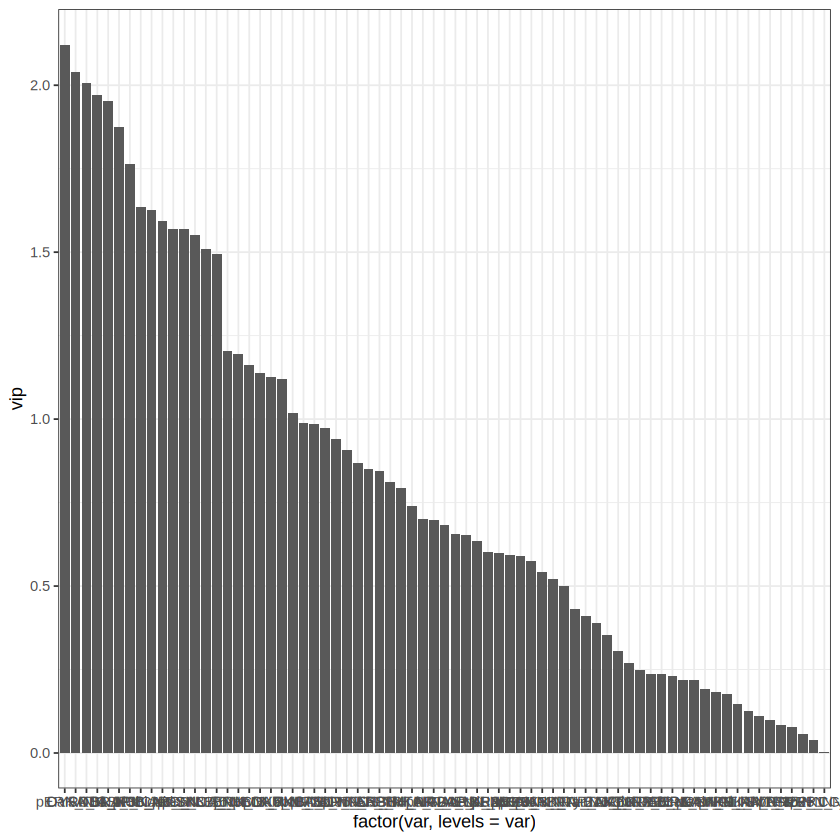

In [169]:
ggplot(df_vip, aes(x= factor(var, levels = var), y = vip)) +
    geom_bar(stat = 'identity') +
    theme_bw()

In [159]:
vip_variables <- df_vip[df_vip$vip > 1, 'var']

In [163]:
df_splot <- DataSplot(train_data[, 6:76], res.oplsda)
df_splot$var <- rownames(df_splot)
df_splot$Vip <- FALSE
df_splot$Vip <- ifelse(df_splot$var %in% vip_variables, TRUE, FALSE)
df_splot$Vip <- as.factor(df_splot$Vip)
head(df_splot)

,Cov,Corr,var,Vip
,<dbl>,<dbl>,<chr>,<fct>
DYRK1A_N,-0.43664265,-0.7619571,DYRK1A_N,TRUE
ITSN1_N,-0.44331452,-0.7409892,ITSN1_N,TRUE
BDNF_N,-0.05288327,-0.3444201,BDNF_N,FALSE
NR1_N,-0.17868743,-0.1638238,NR1_N,FALSE
NR2A_N,-0.75351399,-0.2595388,NR2A_N,FALSE
pAKT_N,0.03159636,0.2649714,pAKT_N,FALSE


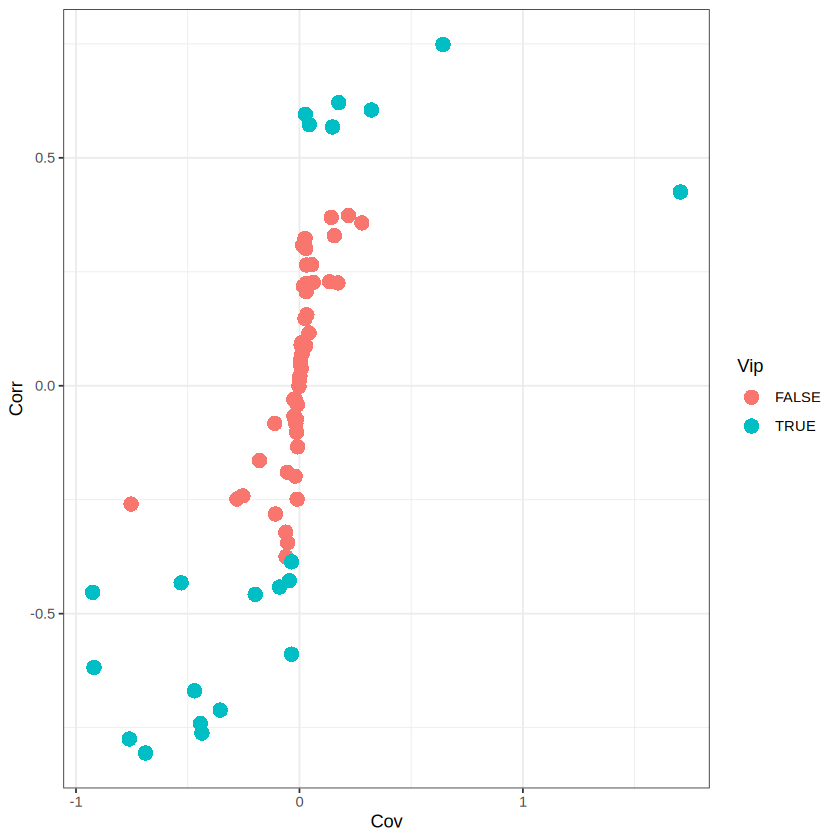

In [167]:
ggplot(df_splot, aes(x = Cov, y = Corr)) +
    geom_point(aes(color = Vip), shape = 16, size = 4) +
    theme_bw()

In [171]:
vip_variables
length(vip_variables)

[1] "pERK_N"      "CaNA_N"      "DYRK1A_N"    "SOD1_N"      "ITSN1_N"    
 [6] "BRAF_N"      "GSK3B_N"     "P38_N"       "pPKCAB_N"    "Ubiquitin_N"
[11] "ARC_N"       "pS6_N"       "pGSK3B_N"    "SNCA_N"      "IL1B_N"     
[16] "S6_N"        "ERK_N"       "pNUMB_N"     "pELK_N"      "CDK5_N"     
[21] "pCAMKII_N"   "NUMB_N"

[1] 22

PLS-DA
779 samples x 22 variables and 1 response
standard scaling of predictors and response(s)
      R2X(cum) R2Y(cum) Q2(cum) RMSEE pre ort  pR2Y   pQ2
Total    0.611    0.873   0.871 0.178   3   0 0.001 0.001


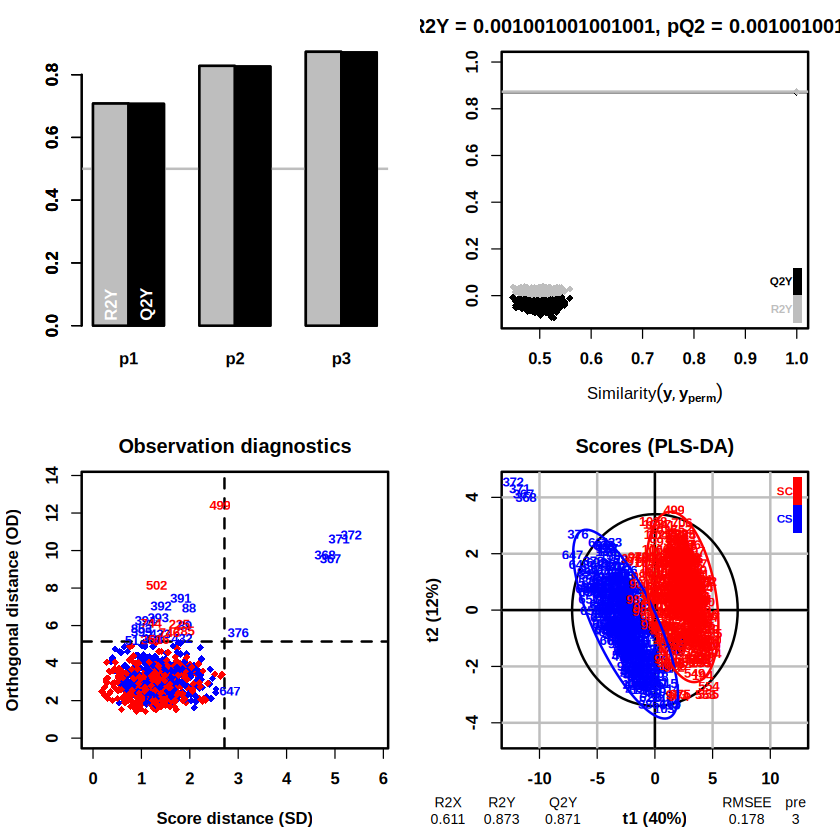

In [174]:
res.plsda2 <- opls(train_data[, vip_variables], train_data$Behavior, 
                  algoC = 'nipals', scaleC = 'standard', 
                  permI = 999, predI = 3)

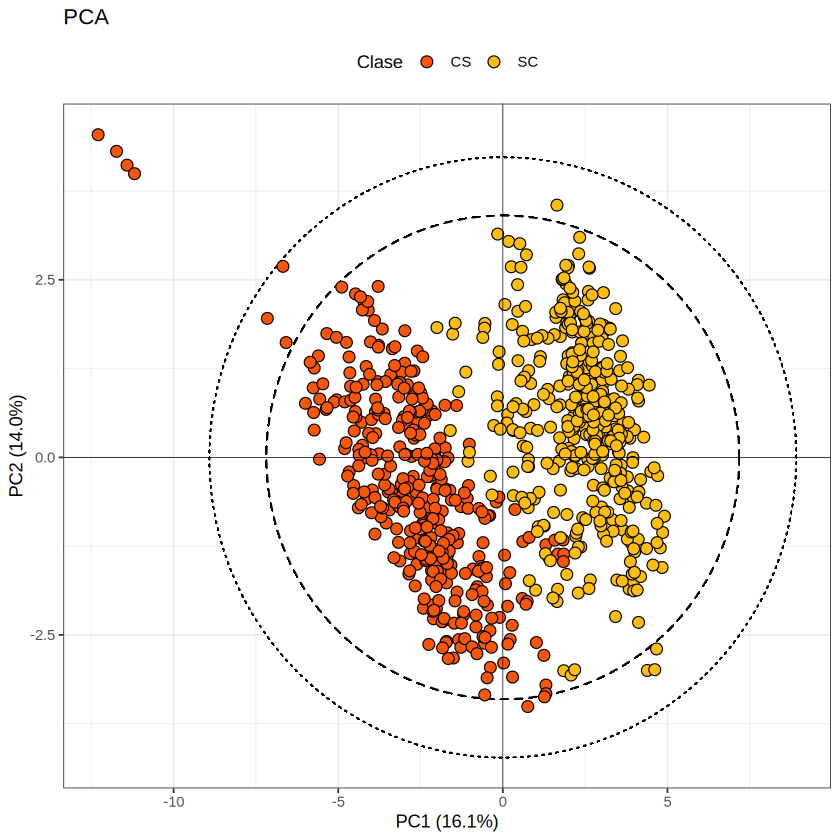

In [175]:
scores <- getScoreMN(res.plsda2)
res_2PCs <- ellipseParam(data = as.data.frame(scores),
                        k = 2, pcx = 1, pcy = 2)
a1 <- res_2PCs$Ellipse$a.99pct
b1 <- res_2PCs$Ellipse$b.99pct
a2 <- res_2PCs$Ellipse$a.95pct
b2 <- res_2PCs$Ellipse$b.95pct

pb <- ggplot(as.data.frame(scores), aes(x = p1, y = p2)) +
        geom_ellipse(aes(x0 = 0, y0 = 0, a = a1, b = b1, angle = 0), size = .5, 
                     linetype = "dotted", fill = "white") +
        geom_ellipse(aes(x0 = 0, y0 = 0, a = a2, b = b2, angle = 0), size = .5, 
                     linetype = "dashed", fill = "white") +
        geom_point(aes(fill = train_data$Behavior), color = 'black', shape = 21, size = 3) +
        scale_fill_manual(values = Behavior_color) +
        geom_hline(yintercept = 0, linetype = "solid", color = "black", size = .2) +
        geom_vline(xintercept = 0, linetype = "solid", color = "black", size = .2) +
        theme_bw() + 
        theme(legend.position = 'top') +
        labs(title = 'PCA', fill = 'Clase') +
        xlab('PC1 (16.1%)') + 
        ylab('PC2 (14.0%)')
pb

In [180]:
confusionMatrix(test_data$Behavior, predict(res.plsda2, test_data[, vip_variables]))

Confusion Matrix and Statistics

          Reference
Prediction  CS  SC
        CS 125   0
        SC   2 132
                                          
               Accuracy : 0.9923          
                 95% CI : (0.9724, 0.9991)
    No Information Rate : 0.5097          
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.9845          
                                          
 Mcnemar's Test P-Value : 0.4795          
                                          
            Sensitivity : 0.9843          
            Specificity : 1.0000          
         Pos Pred Value : 1.0000          
         Neg Pred Value : 0.9851          
             Prevalence : 0.4903          
         Detection Rate : 0.4826          
   Detection Prevalence : 0.4826          
      Balanced Accuracy : 0.9921          
                                          
       'Positive' Class : CS              
                              